In [21]:
import gymnasium as gym
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd
import seaborn as sns

import torch
import torch.nn as nn

one step actor critic

In [22]:
class ValueFcnApprox(nn.Module):
    def __init__(self, d, d2):
        super().__init__()
        self.fc1 = nn.Linear(d, d2)
        self.sig1 = nn.ReLU()
        self.fc2 = nn.Linear(d2, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.sig1(x)
        x = self.fc2(x)
        return x


class PolicyFcnApprox(nn.Module):
    def __init__(self, d, d2):
        super().__init__()
        self.fc1 = nn.Linear(d, d2)
        self.sig1 = nn.ReLU()
        self.fc2 = nn.Linear(d2, d2)
        self.sig2 = nn.ReLU()
        self.fc3 = nn.Linear(d2, 1)
        nn.init.zeros_(self.fc3.bias)


    def forward(self, x):
        x = self.fc1(x)
        x = self.sig1(x)
        x = self.fc2(x)
        x = self.sig2(x)
        x = self.fc3(x)
        return x


In [23]:
#init theta in R^d', init w in R^d
INPUT_DIM = 12
LAYER2_DIM = 64
EPISODES = 100000
GAMMA = 1.0
BETA = 0.05   #entropy bonus

def state_to_idx(s): return s[0]-1, s[1]-1, s[2]

def x(s1, s2, s3):
    player = s1 + 1         
    dealer = s2 + 1  
    soft = float(s3)

    ps = player / 21.0
    ds = dealer / 10.0
    gap = (21 - player) / 21.0 #room under 21
    dealer_weak = float(2 <= dealer <= 6) #basic-strategy "dealer weak"
    dealer_ace = float(dealer == 1)
    hard_bust = 0.0 if soft else max(0.0, (player - 11) / 10.0)

    return np.array([
        1.0,
        ps,
        ds,
        soft,
        gap,
        dealer_weak,
        dealer_ace,
        hard_bust,
        ps * ds,  #player–dealer interaction
        soft * ps, #soft totals behave differently
        dealer_weak * ps, #stand more vs weak dealers as total grows
        gap * soft, #soft hands have more safe gap when counting Ace
    ], dtype=np.float32)

def calculate_return(r_ls, gamma, t, T):
    g = 0.0
    for k in range(T - 1, t - 1, -1):
        g = r_ls[k] + gamma * g
    return g

wins = []

env = gym.make("Blackjack-v1", sab=False)

#init v, theta
model_v = ValueFcnApprox(INPUT_DIM, LAYER2_DIM)
model_p = PolicyFcnApprox(INPUT_DIM, LAYER2_DIM)
optimizer_w = torch.optim.Adam(model_v.parameters(), lr=1e-3)
optimizer_theta = torch.optim.Adam(model_p.parameters(), lr=3e-4)

#for all episodes:
for episode in range(EPISODES):
    #init s
    s, _ = env.reset()
    #I <- 1
    i = 1
    
    #while S not terminal:
    while True:
        #a ~ pi(.), observe r, s'
        s1, s2, s3 = state_to_idx(s)
        xi = torch.tensor(x(s1, s2, s3), dtype=torch.float32)
        p_logits = model_p(xi).squeeze()
        dist = torch.distributions.Bernoulli(logits = p_logits)
        a = dist.sample()
        log_pi = dist.log_prob(a)
        entropy = dist.entropy()


        s_n, r, term, trunc, _ = env.step(int(a.item()))
        s1_n, s2_n, s3_n = state_to_idx(s_n)
        xi_n = torch.tensor(x(s1_n, s2_n, s3_n), dtype=torch.float32)

        v_hat = model_v(xi).squeeze()
        v_n_hat = model_v(xi_n).squeeze()
        #if s' terminal:
        if term or trunc:
            #target update, delta = r - v(s, w)
            delta = r - v_hat
            #update w, w = w + alpha_w * delta * del v(.)
            loss_v = delta**2
            optimizer_w.zero_grad()
            loss_v.backward()
            optimizer_w.step()
            #update theta, theta = theta + alpha_theta * I * delta * del ln(pi(.))
            loss_p = - i * delta.detach() * log_pi - BETA * entropy
            optimizer_theta.zero_grad()
            loss_p.backward()
            optimizer_theta.step()
            
            wins.append(r > 0)
            break

        

        #target update, delta = r + gamma * v(s', w) - v(s, w)
        delta = r + GAMMA * v_n_hat - v_hat
        #update w, w = w + alpha_w * delta * del v(.)
        loss_v = delta ** 2
        optimizer_w.zero_grad()
        loss_v.backward()
        optimizer_w.step()
        #update theta, theta = theta + alpha_theta * I * delta * del ln(pi(.))
        loss_p = -i * delta.detach() * log_pi - BETA * entropy
        optimizer_theta.zero_grad()
        loss_p.backward()
        optimizer_theta.step()

        #I <- gamma * I, s = s'
        i = GAMMA * i
        s = s_n



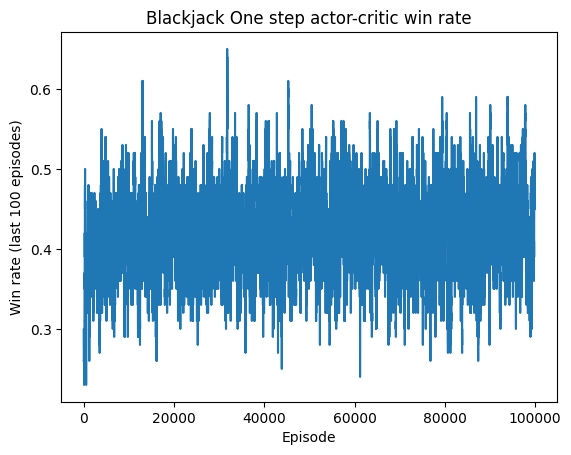

In [24]:
window = 100
win_rate = np.convolve(wins, np.ones(window) / window, mode='valid')

plt.plot(win_rate)
plt.xlabel('Episode')
plt.ylabel(f'Win rate (last {window} episodes)')
plt.title('Blackjack One step actor-critic win rate')
plt.show()

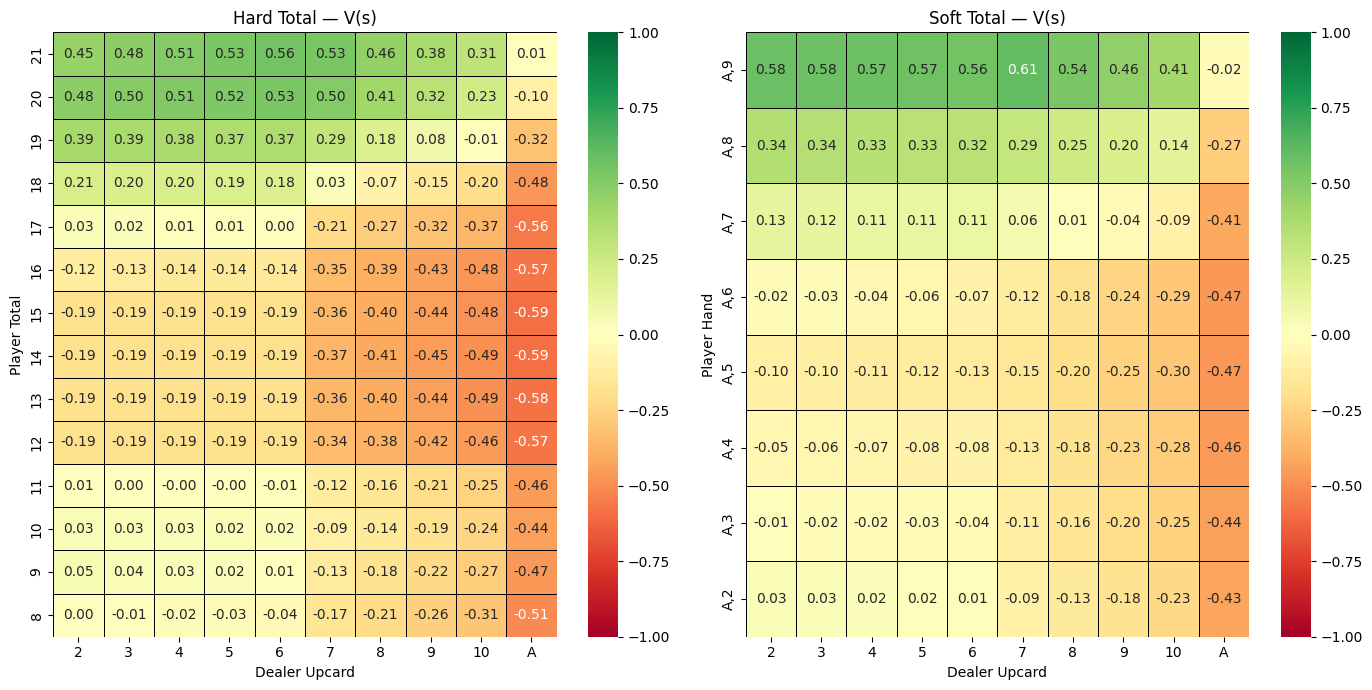

In [25]:
dealer_upcards = [(i, str(i)) for i in range(2, 11)] + [(1, 'A')]

def v_hat(player_sum, dealer_up, usable_ace):
    s1, s2, s3 = player_sum - 1, dealer_up - 1, usable_ace
    xi = torch.tensor(x(s1, s2, s3), dtype=torch.float32)
    with torch.no_grad():
        return model_v(xi).squeeze().item()

hard_table = []
soft_table = []

for player_sum in range(8, 22):
    for dealer_up, dealer_label in dealer_upcards:
        hard_table.append({
            'Player': player_sum,
            'Dealer': dealer_label,
            'Value': v_hat(player_sum, dealer_up, 0),
        })

for player_sum in range(13, 21):
    hand = f"A,{player_sum - 11}"
    for dealer_up, dealer_label in dealer_upcards:
        soft_table.append({
            'Player': hand,
            'Dealer': dealer_label,
            'Value': v_hat(player_sum, dealer_up, 1),
        })

col_order = [str(i) for i in range(2, 11)] + ['A']
soft_hand_order = [f"A,{i}" for i in range(9, 1, -1)]
hard_pivot = pd.DataFrame(hard_table).pivot(index='Player', columns='Dealer', values='Value')[col_order].sort_index(ascending=False)
soft_pivot = pd.DataFrame(soft_table).pivot(index='Player', columns='Dealer', values='Value')[col_order].reindex(soft_hand_order)

plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
sns.heatmap(hard_pivot, cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=.5, linecolor='black', annot=True, fmt='.2f')
plt.title('Hard Total — V(s)')
plt.xlabel('Dealer Upcard')
plt.ylabel('Player Total')

plt.subplot(1, 2, 2)
sns.heatmap(soft_pivot, cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=.5, linecolor='black', annot=True, fmt='.2f')
plt.title('Soft Total — V(s)')
plt.xlabel('Dealer Upcard')
plt.ylabel('Player Hand')

plt.tight_layout()
plt.show()

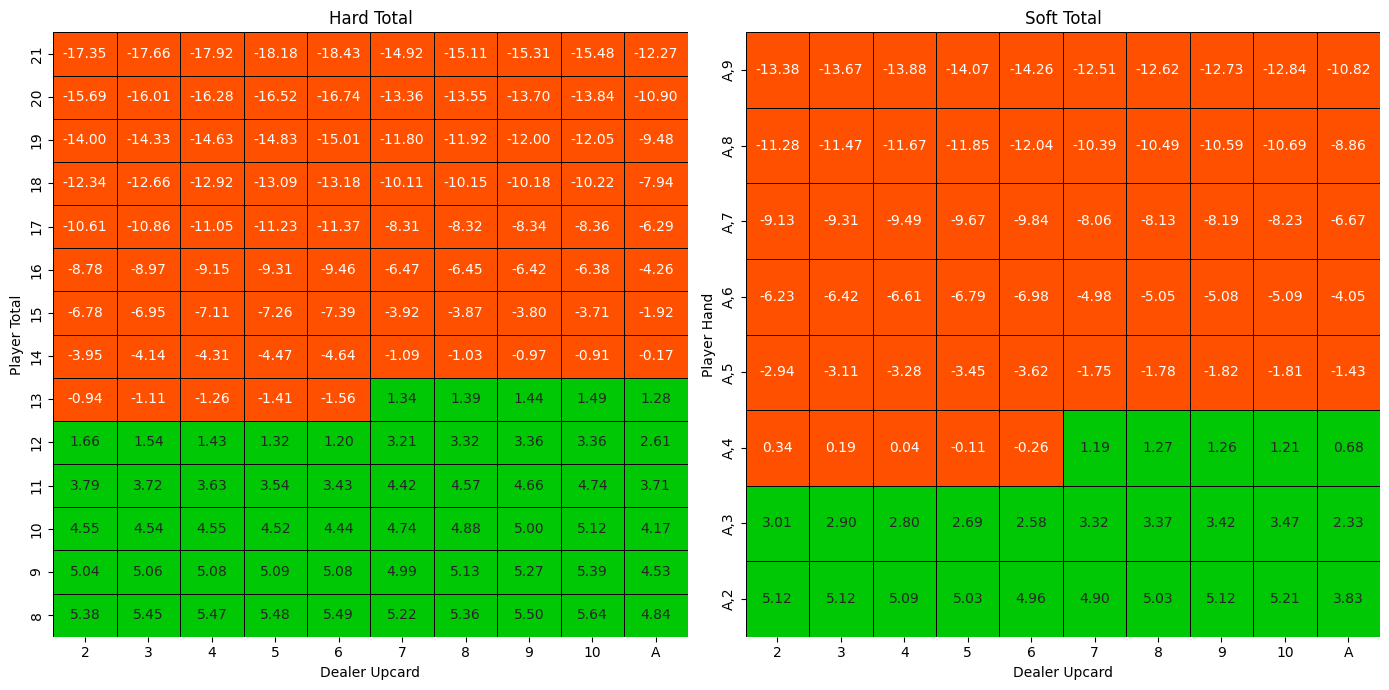

In [26]:

pink = '#FF5000' 
green = '#00C805' 
action_cmap = ListedColormap([pink, green])

def pi_hit(player_sum, dealer_up, usable_ace):
    s1, s2, s3 = player_sum - 1, dealer_up - 1, usable_ace
    xi = torch.tensor(x(s1, s2, s3), dtype=torch.float32)
    with torch.no_grad():
        return model_p(xi).squeeze().item()

dealer_upcards = [(i, str(i)) for i in range(2, 11)] + [(1, 'A')]

hard_table = []
soft_table = []
for player_sum in range(8, 22):
    pi = player_sum - 1
    for dealer_up, dealer_label in dealer_upcards:
        di = dealer_up - 1
        hard_table.append({
            'Player': player_sum,
            'Dealer': dealer_label,
            'P(hit)': pi_hit(player_sum, dealer_up, 0),
        })

for player_sum in range(13, 21):
    pi = player_sum - 1
    hand = f"A,{player_sum - 11}"
    for dealer_up, dealer_label in dealer_upcards:
        di = dealer_up - 1
        soft_table.append({
            'Player': hand,
            'Dealer': dealer_label,
            'P(hit)': pi_hit(player_sum, dealer_up, 1),
        })

col_order = [str(i) for i in range(2, 11)] + ['A']
soft_hand_order = [f"A,{i}" for i in range(9, 1, -1)]
hard_pivot = pd.DataFrame(hard_table).pivot(index='Player', columns='Dealer', values='P(hit)')[col_order].sort_index(ascending=False)
soft_pivot = pd.DataFrame(soft_table).pivot(index='Player', columns='Dealer', values='P(hit)')[col_order].reindex(soft_hand_order)

hard_action = (hard_pivot > 0.5).astype(int)
soft_action = (soft_pivot > 0.5).astype(int)

plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
sns.heatmap(hard_action, cmap=action_cmap, cbar=False,
            linewidths=.5, linecolor='black', annot=hard_pivot, fmt='.2f')
plt.title('Hard Total')
plt.xlabel('Dealer Upcard')
plt.ylabel('Player Total')

plt.subplot(1, 2, 2)
sns.heatmap(soft_action, cmap=action_cmap, cbar=False,
            linewidths=.5, linecolor='black', annot=soft_pivot, fmt='.2f')
plt.title('Soft Total')
plt.xlabel('Dealer Upcard')
plt.ylabel('Player Hand')

plt.tight_layout()
plt.show()